In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [27]:
df = pd.read_csv('titanic.csv')

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [33]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [34]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [40]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [41]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [54]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Survived', ylabel='count'>

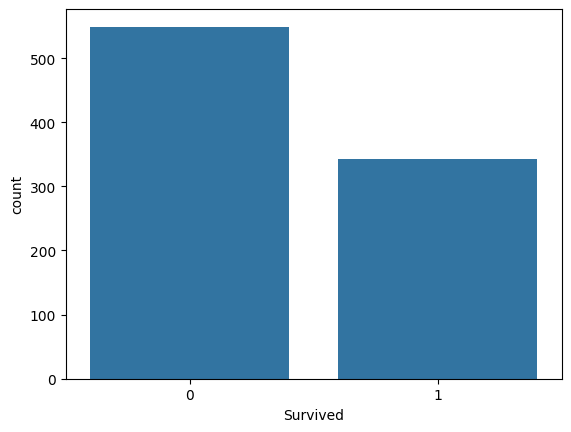

In [58]:
sns.countplot(data=df,x='Survived')

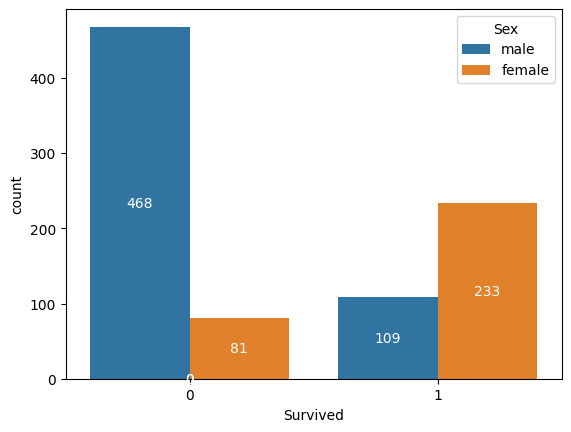

In [63]:
sns.countplot(x='Survived', data=df, hue='Sex')
ax = plt.gca()
for p in ax.patches:
    h = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        h/2,
        int(h),
        va='center',
        ha='center',
        color='white'
        )

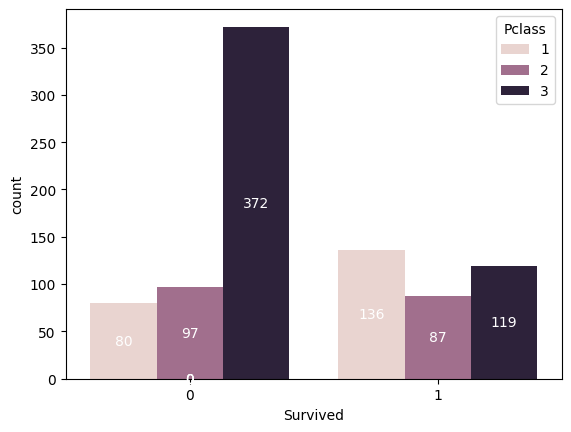

In [65]:
sns.countplot(x='Survived', data=df, hue='Pclass')
ax = plt.gca()
for p in ax.patches:
    h = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        h/2,
        int(h),
        va='center',
        ha='center',
        color='white'
        )

<Axes: xlabel='Age', ylabel='Count'>

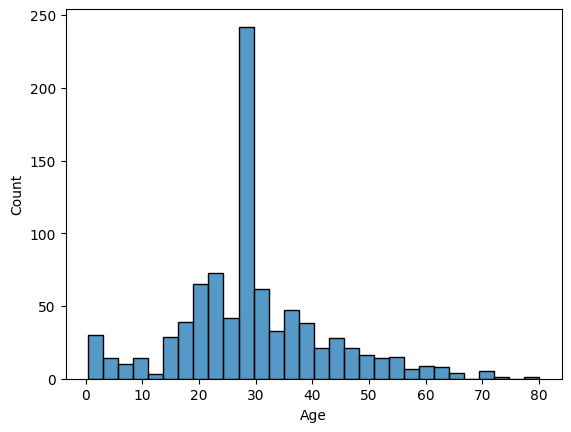

In [67]:
sns.histplot(x='Age', data=df)

<Axes: xlabel='Survived', ylabel='Fare'>

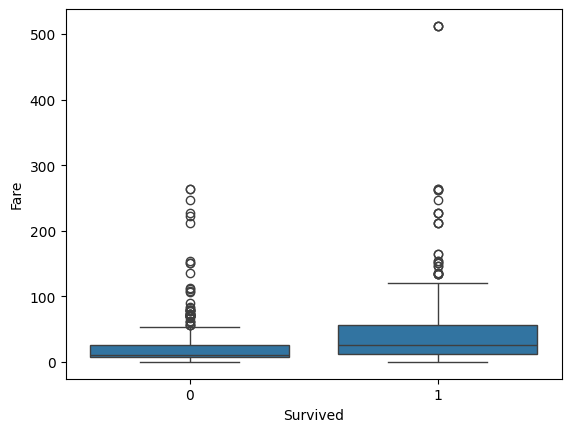

In [75]:
sns.boxplot(x='Survived', y='Fare', data=df)

In [79]:
df[df['Survived']==0].describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,549.0,447.016393,260.640469,1.0,211.0000,455.0,675.0,891.0
Survived,549.0,0.000000,0.000000,0.0,0.0000,0.0,0.0,0.0
Pclass,549.0,2.531876,0.735805,1.0,2.0000,3.0,3.0,3.0
Age,549.0,30.028233,12.499986,1.0,23.0000,28.0,35.0,74.0
SibSp,549.0,0.553734,1.288399,0.0,0.0000,0.0,1.0,8.0
Parch,549.0,0.329690,0.823166,0.0,0.0000,0.0,0.0,6.0
Fare,549.0,22.117887,31.388207,0.0,7.8542,10.5,26.0,263.0


In [81]:
df[df['Survived']==1].describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,342.0,444.368421,252.358840,2.00,250.750,439.5,651.5,890.0000
Survived,342.0,1.000000,0.000000,1.00,1.000,1.0,1.0,1.0000
Pclass,342.0,1.950292,0.863321,1.00,1.000,2.0,3.0,3.0000
Age,342.0,28.291433,13.764425,0.42,21.000,28.0,35.0,80.0000
SibSp,342.0,0.473684,0.708688,0.00,0.000,0.0,1.0,4.0000
Parch,342.0,0.464912,0.771712,0.00,0.000,0.0,1.0,5.0000
Fare,342.0,48.395408,66.596998,0.00,12.475,26.0,57.0,512.3292


<Axes: >

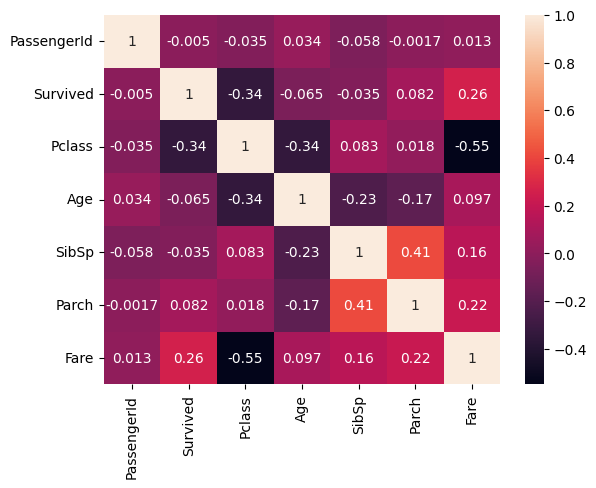

In [85]:
# correlation between the variables
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)